# Generative Models and Uncertainty

The deep learning architectures we have seen so far, the
[artificial neural network](../DeepLearning/ann.ipynb), the
[convolutional neural network](../DeepLearning/cnn.ipynb), and the
[recurrent neural network](../DeepLearning/rnn.ipynb), are all *discriminative*:
given an input, they predict a single output. This page begins the Advanced
Topics unit with **generative modeling**, where a model instead predicts a
*distribution* of possible outputs. We will:

- Define **generative modeling** and contrast it with what we have seen before.
- Distinguish **aleatoric** from **epistemic** uncertainty.
- Survey the main ways of **adding uncertainty** to machine learning models.
- Learn to **evaluate** uncertainty estimates, with the spread vs. skill plot
  and the **continuous ranked probability score (CRPS)**.

The [next page](gansdiffusion.ipynb) covers two state-of-the-art generative
architectures, GANs and diffusion models, and the [page after
that](vaes.ipynb) covers a third, the variational autoencoder, together with
the scientific uses of its latent representations.

## Why include uncertainty?

Consider a downscaling problem from the satellite literature (Leinonen et al.
2020). We observe a *low resolution* satellite image of rain rates: each coarse
pixel averages over many fine ones, so information about the small scale
structure has been lost. Now we ask a machine learning model to reconstruct the
*high resolution* rain field. There is no longer a single right answer: many
different fine scale fields would average to exactly the same coarse image, and
the low resolution input does not contain enough information to discriminate
between them.

A model trained to output one answer must collapse all of those possibilities
onto a single field. **Without including uncertainty, machine learning models
can be overconfident in their predictions**: the one field they return may look
plausible while being far from the truth, and nothing in the output warns us.
What we would rather have is the *distribution* of rain fields consistent with
the input. An ensemble of samples from that distribution tells us what the
probable rain rates are, and how much they could vary.

That is what a generative model is: a statistical model that predicts a **joint
probability distribution** over its variables, so that given an input $x$ it
can return a conditional distribution $p(y \mid x)$ of outputs rather than a
single output vector $y$.

## Two kinds of uncertainty

Machine learning distinguishes two sources of uncertainty (Abdar et al. 2021):

- **Aleatoric uncertainty** is the irreducible scatter in the system itself,
  for example measurement noise, or true stochasticity in the process. No
  amount of extra data removes it.
- **Epistemic uncertainty** comes from not having seen enough data. Where we
  have few or no observations, many different models fit equally well. More
  measurements *can* reduce it.

The distinction matters because the two call for different remedies: a
generative model can learn to *represent* the aleatoric spread, but only more
observations (or an honest admission of ignorance) address the epistemic part.
The toy example below makes both visible.

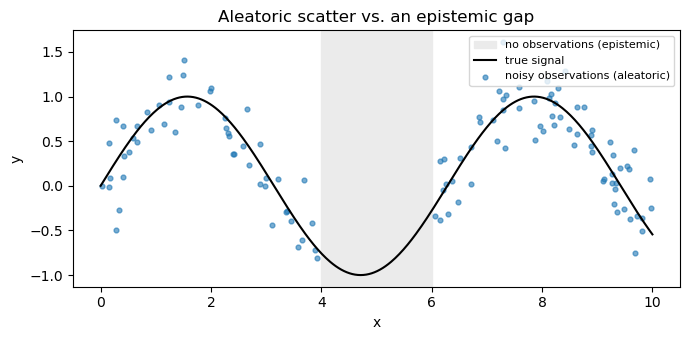

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

def truth(x):
    return np.sin(x)

# noisy observations of a sine wave, with a gap between x = 4 and x = 6
x_obs = rng.uniform(0, 10, 150)
x_obs = x_obs[(x_obs < 4) | (x_obs > 6)]
y_obs = truth(x_obs) + 0.25 * rng.standard_normal(len(x_obs))

xg = np.linspace(0, 10, 400)
plt.figure(figsize=(7, 3.5))
plt.axvspan(4, 6, color="0.92", label="no observations (epistemic)")
plt.plot(xg, truth(xg), "k", lw=1.5, label="true signal")
plt.scatter(x_obs, y_obs, s=12, alpha=0.6, label="noisy observations (aleatoric)")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(loc="upper right", fontsize=8)
plt.title("Aleatoric scatter vs. an epistemic gap")
plt.tight_layout(); plt.show()

The vertical scatter of the points around the black curve is the aleatoric
uncertainty: even with infinite data, single observations would still miss the
curve by about the noise level. The shaded band is epistemic: the signal keeps
oscillating there, but nothing in our data says so, and a model is free to do
almost anything across the gap. Measuring inside the band would shrink that
uncertainty; measuring more outside it would not.

## Ways to add uncertainty to a neural network

In practice there are several ways to make a network produce a distribution
instead of a point estimate (Haynes et al. 2023). None is universally best; they
trade training cost, inference cost, and how much of the uncertainty they
capture.

1. **Learn the ensemble directly.** Train one network to output $K$ target
   values instead of one, so the model learns an ensemble prediction in a
   single forward pass. This needs ground truth ensembles (or a lot of data).
2. **Multi-model ensembles.** Train several independent networks that differ
   only in their random initialization (and the randomness of optimization).
   Their predictions disagree most where the data constrain them least, so the
   spread across members estimates epistemic uncertainty. This is often called
   a *deep ensemble*.
3. **Predict distribution parameters.** If the target is plausibly Gaussian,
   let the network output $\mu$ and $\sigma$ rather than $y$; more complex
   parametric distributions work the same way.
4. **Predict summary statistics.** Instead of the parameters, output a set of
   *quantiles* of the target distribution.
5. **Monte Carlo dropout.** Dropout randomly zeroes a fraction of weights in
   each layer. During training this regularizes the model. If we *keep dropout
   on during inference*, every forward pass uses a slightly different
   subnetwork, so repeating the prediction many times yields a spread of
   outputs: uncertainty quantification almost for free.

Below we build a small deep ensemble (option 2) on the toy data: ten identical
networks that differ only in `random_state`. To see where the members disagree,
we also ask them to predict past $x = 10$, beyond the last observation.

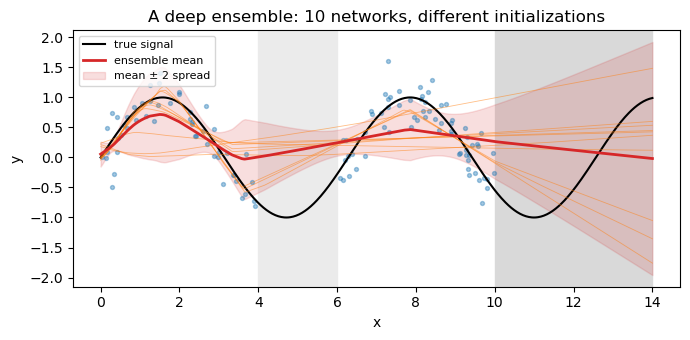

mean ensemble spread where we have data:  0.213
mean ensemble spread in the interior gap: 0.186
mean ensemble spread beyond x = 10:       0.635


In [2]:
from sklearn.neural_network import MLPRegressor

X = x_obs.reshape(-1, 1)
ensemble = [
    MLPRegressor(hidden_layer_sizes=(50, 50), activation="relu",
                 max_iter=4000, random_state=s).fit(X, y_obs)
    for s in range(10)
]
xg = np.linspace(0, 14, 560)        # extends past the last observation at x = 10
preds = np.array([m.predict(xg.reshape(-1, 1)) for m in ensemble])
ens_mean, ens_spread = preds.mean(axis=0), preds.std(axis=0)

plt.figure(figsize=(7, 3.5))
plt.axvspan(4, 6, color="0.92")
plt.axvspan(10, 14, color="0.85")
plt.plot(xg, truth(xg), "k", lw=1.5, label="true signal")
plt.plot(xg, preds.T, color="tab:orange", lw=0.6, alpha=0.5)
plt.plot(xg, ens_mean, color="tab:red", lw=2, label="ensemble mean")
plt.fill_between(xg, ens_mean - 2 * ens_spread, ens_mean + 2 * ens_spread,
                 color="tab:red", alpha=0.15, label="mean ± 2 spread")
plt.scatter(x_obs, y_obs, s=8, alpha=0.4)
plt.xlabel("x"); plt.ylabel("y"); plt.legend(loc="upper left", fontsize=8)
plt.title("A deep ensemble: 10 networks, different initializations")
plt.tight_layout(); plt.show()

gap = (xg > 4) & (xg < 6)
beyond = xg > 10
data_region = ~gap & ~beyond
print(f"mean ensemble spread where we have data:  {ens_spread[data_region].mean():.3f}")
print(f"mean ensemble spread in the interior gap: {ens_spread[gap].mean():.3f}")
print(f"mean ensemble spread beyond x = 10:       {ens_spread[beyond].mean():.3f}")

Each thin orange line is one trained network. Beyond the edge of the data the
members fan out dramatically, each extrapolating in its own direction, and the
printed numbers confirm it: the spread past $x = 10$ is about three times the
spread over the observed region. The ensemble has *discovered* its own
epistemic uncertainty there, without ever being told where the data end.

The interior gap teaches a subtler lesson. The members bridge it in nearly the
same way, so the spread there is *no larger* than where we have data, even
though the truth (which keeps oscillating) is far from all of them. With data
on both sides, every network interpolates similarly and the ensemble stays
confidently wrong. Deep ensembles reveal epistemic uncertainty most reliably
under extrapolation; they can remain overconfident when interpolating across
a gap, which is worth remembering whenever an ensemble looks reassuringly
tight.

## Evaluating predicted distributions: spread vs. skill

Once a model outputs distributions, evaluation has to change too. A first
diagnostic borrowed from ensemble weather forecasting is the **spread vs.
skill plot**:

- **Spread** is the uncertainty across ensemble members (their standard
  deviation).
- **Skill** is the accuracy of the ensemble mean (its absolute error).

For a well calibrated ensemble the two should match on average: when the
ensemble claims a spread of 0.2, the mean should typically be wrong by about
0.2. Plotting binned skill against spread, a reliable ensemble follows the
one-to-one line. Points **above** the line (error larger than spread) mean the
ensemble is *overconfident*, or under-dispersive: it does not capture the true
range of outcomes. Points **below** it mean the ensemble is *underconfident*.
The plot answers two questions at once: does the ensemble capture the range of
possible outcomes, and is the ensemble mean a reliable prediction?

An operational spread vs. skill plot aggregates over thousands of forecasts;
here we only have the one toy problem, so we bin the 560 grid points by their
ensemble spread and compare the average spread to the average error in each
bin.

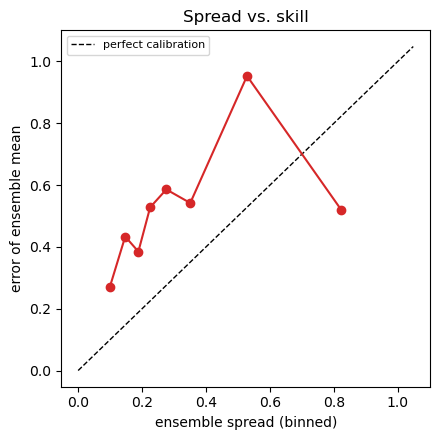

correlation between spread and error: 0.29


In [3]:
err = np.abs(ens_mean - truth(xg))

# bin points by ensemble spread and compare mean spread to mean error per bin
bins = np.quantile(ens_spread, np.linspace(0, 1, 9))
which = np.digitize(ens_spread, bins[1:-1])
bin_spread = np.array([ens_spread[which == b].mean() for b in range(8)])
bin_err = np.array([err[which == b].mean() for b in range(8)])

plt.figure(figsize=(4.5, 4.5))
lim = max(bin_spread.max(), bin_err.max()) * 1.1
plt.plot([0, lim], [0, lim], "k--", lw=1, label="perfect calibration")
plt.plot(bin_spread, bin_err, "o-", color="tab:red")
plt.xlabel("ensemble spread (binned)"); plt.ylabel("error of ensemble mean")
plt.title("Spread vs. skill"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"correlation between spread and error: {np.corrcoef(ens_spread, err)[0, 1]:.2f}")

Through most of the range, bins with larger spread have larger error: spread is
doing its job as a predictor of error. Two honest caveats are visible too.
First, every bin sits *above* the one-to-one line, meaning the error is
consistently larger than the spread claims: the ensemble is under-dispersive,
or overconfident, a very common finding for deep ensembles, whose members
(differing only in initialization) rarely fan out as widely as the true range
of possibilities. Second, the largest spread bin breaks the trend: at extreme
extrapolation the members fan out so symmetrically that their mean lands near
the middle by construction, and with a single toy realization these statistics
are noisy anyway. Diagnostics like this one are only trustworthy when averaged
over many cases.

## The continuous ranked probability score

Spread vs. skill diagnoses calibration, but we also want a single score to
*compare* probabilistic models, the way MAE or MSE compares deterministic
ones. The standard choice is the **continuous ranked probability score**:

$$\mathrm{CRPS}(F, y) = \int_{-\infty}^{\infty}
\left( F(z) - \mathbb{1}\{z \ge y\} \right)^2 \, dz$$

where $F$ is the forecast's cumulative distribution function (CDF) and $y$ is
the observed value. Graphically: draw the forecast CDF, draw the step function
that jumps from 0 to 1 at the observation, and add up the squared area between
them. A sharp forecast centered on the observation makes that area small, so
**lower CRPS is better**. If the forecast is a single deterministic value, its
CDF is itself a step function and the CRPS **reduces exactly to the mean
absolute error**, which is what makes it a genuine generalization of the
deterministic metrics we already use.

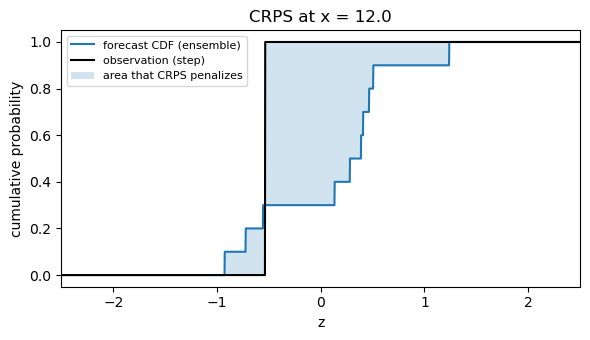

observation y = -0.537
CRPS of the 10-member ensemble:      0.436
CRPS of a single member:             0.817
|error| of that member (MAE check):  0.817


In [4]:
def crps_from_samples(samples, y, zgrid):
    "CRPS of an empirical (ensemble) forecast, by numerical integration."
    F = (np.sort(samples)[:, None] <= zgrid[None, :]).mean(axis=0)
    H = (zgrid >= y).astype(float)
    return np.trapz((F - H) ** 2, zgrid)

# evaluate at one point beyond the data, where the members disagree
x0 = 12.0
i0 = np.argmin(np.abs(xg - x0))
members = preds[:, i0]
y0 = truth(x0)
zg = np.linspace(-5, 5, 4001)

F = (np.sort(members)[:, None] <= zg[None, :]).mean(axis=0)
H = (zg >= y0).astype(float)

plt.figure(figsize=(6, 3.5))
plt.plot(zg, F, label="forecast CDF (ensemble)")
plt.plot(zg, H, "k", label="observation (step)")
plt.fill_between(zg, F, H, alpha=0.2, label="area that CRPS penalizes")
plt.xlim(-2.5, 2.5); plt.xlabel("z"); plt.ylabel("cumulative probability")
plt.title(f"CRPS at x = {x0}"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

crps_ens = crps_from_samples(members, y0, zg)
det = members[0]                       # a single deterministic forecast
crps_det = crps_from_samples(np.array([det]), y0, zg)
print(f"observation y = {y0:.3f}")
print(f"CRPS of the 10-member ensemble:      {crps_ens:.3f}")
print(f"CRPS of a single member:             {crps_det:.3f}")
print(f"|error| of that member (MAE check):  {abs(det - y0):.3f}")

The printed numbers make both claims of the previous section concrete. First,
the CRPS of the single deterministic member equals its absolute error (up to
the resolution of the integration grid): CRPS really does reduce to MAE in the
deterministic case. Second, at this point beyond the data, where the members
genuinely disagree, the ensemble scores markedly better than the single
member: spreading probability over the plausible range is rewarded when any
one point prediction is likely to be off.

## Summary

- Generative models predict **distributions of outputs** rather than single
  vectors, which lets them express uncertainty instead of hiding it.
- **Aleatoric** uncertainty is irreducible scatter; **epistemic** uncertainty
  reflects missing data and can be reduced by observing more.
- Practical routes to uncertainty: learned ensembles, deep ensembles,
  predicted distribution parameters, predicted quantiles, and Monte Carlo
  dropout.
- Evaluate probabilistic predictions with **spread vs. skill** for calibration
  and **CRPS** for scoring; CRPS generalizes MAE.

The [next page](gansdiffusion.ipynb) introduces the first two of three
state-of-the-art generative architectures: generative adversarial networks and
diffusion models.